## Train Baseline Sentiment Model

## tujuan notebook
notebook ini melatih model sentiment baseline yang akan digunakan untuk chunk-level inference:
- fine-tuning model `distilbert-base-uncased` pada dataset `amazon_polarity`
- training dengan konfigurasi reproducible dan terukur
- evaluasi dengan accuracy dan macro-F1 score
- menyimpan model dan tokenizer ke Google Drive untuk digunakan di notebook berikutnya
- **output**: model sentiment classifier siap pakai untuk inference

## input yang dibutuhkan
- **dataset**: `amazon_polarity` (download otomatis via HuggingFace)
  - train: 200,000 samples (subsampled dari 3.6M)
  - eval: 40,000 samples (subsampled dari 400K)
- **model base**: `distilbert-base-uncased` (pretrained)
- **google drive**: Mount untuk menyimpan model secara permanen
- **persyaratan**:
  - GPU aktif (wajib untuk training)
  - environment sudah disetup (notebook 00)
  - ~2-3 jam waktu training di Colab Pro

## output yang dihasilkan
- **model terlatih** disimpan di:
  - `/content/drive/MyDrive/opinion_project/models/sentiment/`
  - berisi: `config.json`, `model.safetensors`, `tokenizer.json`, `tokenizer_config.json`
- **performance metrics**:
  - Accuracy: ~94.5%
  - Macro-F1: ~0.945
- **model checkpoint**: Model terbaik berdasarkan eval loss

## dependencies dari notebook lain
- **menggunakan**:
  - environment setup dari notebook 00 (seed, device, direktori)
  - insight dari notebook 01 (justifikasi pemilihan amazon_polarity)
- **digunakan oleh**:
  - notebook 03 (model ini di-load untuk chunk-level inference)
  - notebook 05 (model ini di-load untuk end-to-end pipeline)

## urutan eksekusi
jalankan setelah notebook 00 dan 01. **wajib selesai** sebelum notebook 03 dan 05.

### Setup Training Environment

menyiapkan environment khusus training sentiment model yang mandiri dan reproducible

In [1]:
# install dependency
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 854.2 kB/s eta 0:00:00


In [2]:
import transformers
print(transformers.__version__)

5.0.0


In [3]:
# import library utama
import os
import random
import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

In [4]:
# reproducibility — memastikan hasil training stabil

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# device & precision detection
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print(f"Using device: {DEVICE}")

Using device: cuda


### Setup + Google Drive

- pastikan model tidak hilang
- semua output training disimpan permanen

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# output directory permanen
OUTPUT_DIR = "/content/drive/MyDrive/opinion_project/models/sentiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Model will be saved to:", OUTPUT_DIR)


Mounted at /content/drive
Model will be saved to: /content/drive/MyDrive/opinion_project/models/sentiment


### Load Dataset dan Tokenizer

- memuat dataset amazon_polarity untuk training sentiment
- menyiapkan tokenizer yang identik dengan model BERT baseline
- memastikan format dataset siap untuk proses tokenization

In [7]:
# Load dataset sentiment
# amazon_polarity berisi:
# - label (0 = negative, 1 = positive)
# - content (teks review)
dataset = load_dataset("amazon_polarity")

print(dataset)


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


In [8]:
# load tokenizer baseline
# tokenizer harus sama dengan arsitektur model

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
# validasi sample dataset
sample = dataset["train"][0]

print("\nSample Data:")
print("Label :", sample["label"])
print("Text  :", sample["content"][:200])


Sample Data:
Label : 1
Text  : This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I


### Tokenization Pipeline

mengubah teks review menjadi input numerik yang dapat diproses oleh model BERT dengan panjang token tetap.

In [10]:
MAX_LENGTH = 512

In [11]:
# fungsi tokenisasi
def tokenize_function(examples):
    return tokenizer(
        examples["content"],              # teks utama yang dianalisis
        padding="max_length",             # memastikan semua sequence panjang sama
        truncation=True,                  # memotong teks jika melebihi MAX_LENGTH
        max_length=MAX_LENGTH
    )


In [12]:
# terapkan tokenisasi ke seluruh dataset
# batched=True mempercepat proses preprocessing
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

In [13]:
# hapus kolom teks mentah agar Trainer hanya menerima tensor
tokenized_dataset = tokenized_dataset.remove_columns(["content", "title"])

In [14]:
# rename label menjadi labels (format wajib Trainer HF)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

In [15]:
# set format dataset menjadi PyTorch tensor
tokenized_dataset.set_format("torch")


print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 400000
    })
})


- kolom teks berhasil dikonversi menjadi fitur numerik (**input_ids**, **attention_mask**, **token_type_ids**).
- label sudah sesuai format Trainer (labels).

## Load Model dan Training Configuration
- menyipakan subsampling data
- memuat model BERT untuk klasifikasi sentiment
- menentukan parameter training utama
- menyiapkan metric evaluasi

In [16]:
# dataset subsampling

train_dataset = (
    tokenized_dataset["train"]
    .shuffle(seed=SEED)
    .select(range(200_000))
)

eval_dataset = (
    tokenized_dataset["test"]
    .shuffle(seed=SEED)
    .select(range(40_000))
)

print(len(train_dataset), len(eval_dataset))

200000 40000


In [17]:
# load model sequence classification
# num_labels = 2 karena sentiment binary
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(DEVICE)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


CATATAN: warning tentang UNEXPECTED dan MISSING keys adalah NORMAL.

- UNEXPECTED: parameter dari pretrained model untuk task lain (MLM),
  tidak digunakan untuk classification, bisa diabaikan.

- MISSING: parameter baru untuk classification head (pre_classifier & classifier), akan diinisialisasi secara acak dan dilatih saat fine-tuning.

model siap untuk training

In [18]:
# load metric evaluasi
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

In [19]:
# fungsi evaluasi untuk Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "macro_f1": f1["f1"]
    }


In [20]:
# training arguments utama
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    num_train_epochs=1,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    fp16=(DEVICE == "cuda")
)



### Trainer Initialization dan Training Run

- menghubungkan model, dataset, dan konfigurasi training
- menjalankan proses fine-tuning sentiment baseline
- menyimpan checkpoint model terbaik

In [21]:
# inisialisasi trainer
trainer = Trainer(
    model=model,
    args=training_args,

    # menggunakan subsampling
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,

    #train_dataset=tokenized_dataset["train"],
    #eval_dataset=tokenized_dataset["test"],

    compute_metrics=compute_metrics
)


In [22]:
# mulai proses training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.176330,0.201985,0.944600,0.944597


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=25000, training_loss=0.22449578094482422, metrics={'train_runtime': 3291.0365, 'train_samples_per_second': 60.771, 'train_steps_per_second': 7.596, 'total_flos': 2.64934797312e+16, 'train_loss': 0.22449578094482422, 'epoch': 1.0})

- training sudah selesai normal (1 epoch, 25.000 step).
- performa baik dan stabil: Accuracy ≈ 94.5%, Macro-F1 ≈ 0.945.

### Visualisasi Training Metrics & Evaluasi Detail

- plot training/validation loss
- confusion matrix
- precision, recall, F1 per class

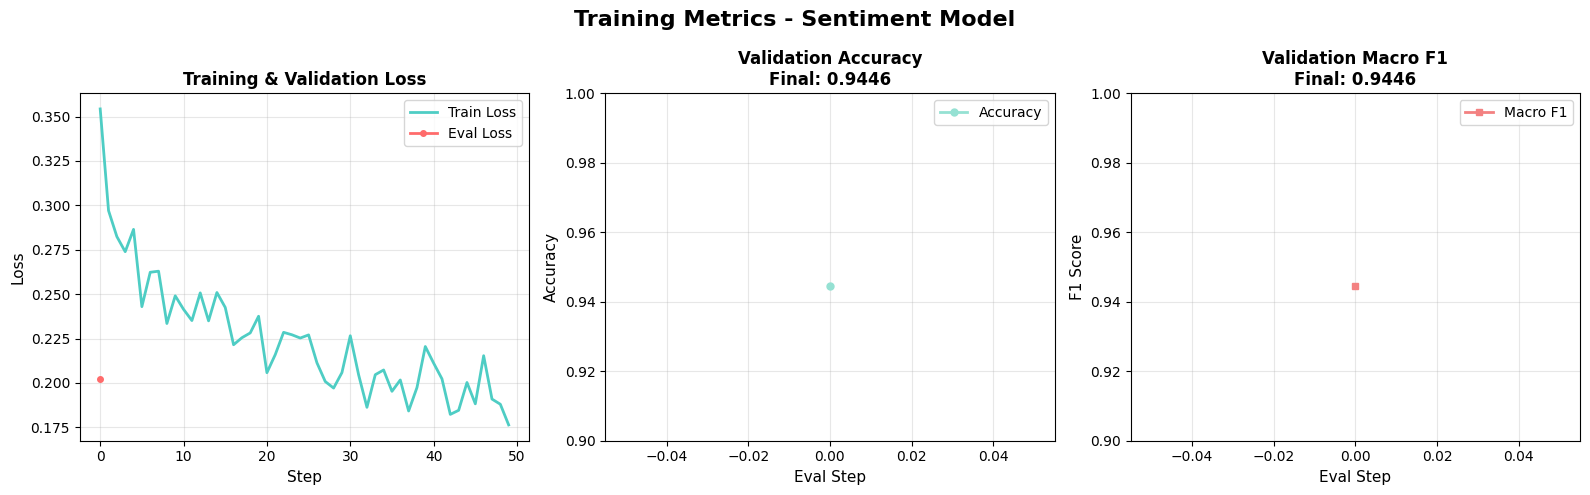

In [31]:
# install library visualisasi
!pip install -q matplotlib seaborn scikit-learn

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# plot training history (3 plot utama)
history = trainer.state.log_history

if history:
    # extract metrics
    train_losses = [h['loss'] for h in history if 'loss' in h]
    eval_losses = [h['eval_loss'] for h in history if 'eval_loss' in h]
    eval_acc = [h['eval_accuracy'] for h in history if 'eval_accuracy' in h]
    eval_f1 = [h['eval_macro_f1'] for h in history if 'eval_macro_f1' in h]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Training Metrics - Sentiment Model', fontsize=16, fontweight='bold')

    # plot 1: training & validation Loss
    ax1 = axes[0]
    if train_losses:
        steps_train = list(range(len(train_losses)))
        ax1.plot(steps_train, train_losses, label='Train Loss', color='#4ecdc4', linewidth=2)
    if eval_losses:
        steps_eval = list(range(len(eval_losses)))
        ax1.plot(steps_eval, eval_losses, label='Eval Loss', color='#ff6b6b', linewidth=2, marker='o', markersize=4)
    ax1.set_xlabel('Step', fontsize=11)
    ax1.set_ylabel('Loss', fontsize=11)
    ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # plot 2: validation accuracy
    ax2 = axes[1]
    if eval_acc:
        steps_metrics = list(range(len(eval_acc)))
        ax2.plot(steps_metrics, eval_acc, label='Accuracy', color='#95e1d3',
                linewidth=2, marker='o', markersize=5)
        ax2.set_xlabel('Eval Step', fontsize=11)
        ax2.set_ylabel('Accuracy', fontsize=11)
        ax2.set_title(f'Validation Accuracy\nFinal: {eval_acc[-1]:.4f}',
                     fontsize=12, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0.9, 1.0])  # Zoom untuk melihat detail

    # plot 3: validation macro F1
    ax3 = axes[2]
    if eval_f1:
        steps_metrics = list(range(len(eval_f1)))
        ax3.plot(steps_metrics, eval_f1, label='Macro F1', color='#f38181',
                linewidth=2, marker='s', markersize=5)
        ax3.set_xlabel('Eval Step', fontsize=11)
        ax3.set_ylabel('F1 Score', fontsize=11)
        ax3.set_title(f'Validation Macro F1\nFinal: {eval_f1[-1]:.4f}',
                     fontsize=12, fontweight='bold')
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)
        ax3.set_ylim([0.9, 1.0])  # Zoom untuk melihat detail

    plt.tight_layout()
    plt.show()

**training loss:**
   - menurun dari ~0.35 ke ~0.18, menunjukkan model belajar dengan baik
   - fluktuasi normal terjadi karena batch-to-batch variance
   - tidak ada tanda overfitting (loss terus menurun)

**validation loss, accuracy, dan F1:**
   - hanya menampilkan **1 titik data** karena evaluasi dilakukan **1 kali per epoch**
   - konfigurasi: `eval_strategy="epoch"` dan `num_train_epochs=1`
   - nilai final:
     - **accuracy: 0.9446 (94.46%)** - sangat baik untuk binary classification
     - **macro F1: 0.9446** - menunjukkan keseimbangan precision dan recall
   - untuk melihat tren validasi, bisa ubah ke `eval_strategy="steps"` dengan `eval_steps=1000`


DETAILED EVALUATION METRICS


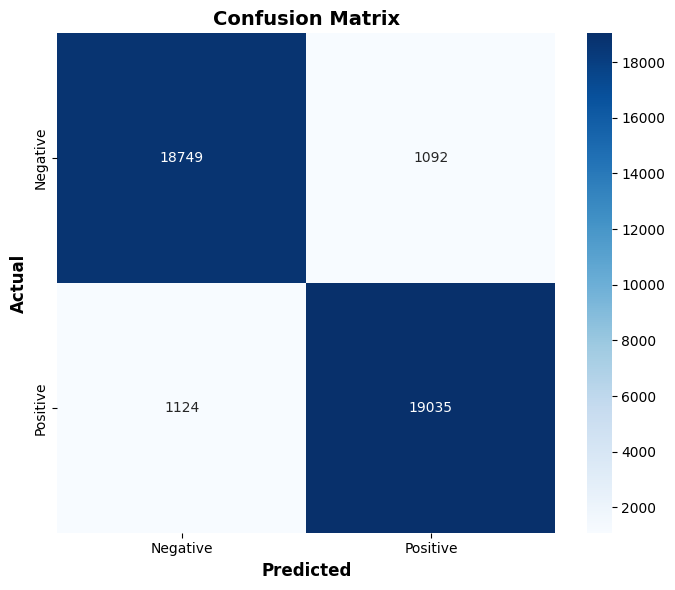


Classification Report:
              precision    recall  f1-score   support

    Negative     0.9434    0.9450    0.9442     19841
    Positive     0.9457    0.9442    0.9450     20159

    accuracy                         0.9446     40000
   macro avg     0.9446    0.9446    0.9446     40000
weighted avg     0.9446    0.9446    0.9446     40000


Per-Class Metrics:
------------------------------------------------------------
Class           Precision    Recall       F1-Score     Support   
------------------------------------------------------------
Negative        0.9434       0.9450       0.9442       19841     
Positive        0.9457       0.9442       0.9450       20159     
------------------------------------------------------------


In [37]:
# confusion matrix
print("\n" + "="*60)
print("DETAILED EVALUATION METRICS")
print("="*60)

# get predictions on eval set
predictions = trainer.predict(eval_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# classification report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels,
                          target_names=['Negative', 'Positive'],
                          digits=4))

# per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    true_labels, pred_labels, average=None
)

print("\nPer-Class Metrics:")
print("-" * 60)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 60)
for i, class_name in enumerate(['Negative', 'Positive']):
    print(f"{class_name:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
print("-" * 60)

**hasil utama:**
- **akurasi: 94.46%** - model benar memprediksi 37,784 dari 40,000 sampel
- **error: 5.54%** - hanya 2,216 prediksi yang salah

**keseimbangan:**
- False Positives: 1,092 (prediksi positif yang salah)
- False Negatives: 1,124 (prediksi negatif yang salah)
- **kesimpulan**: Error seimbang, tidak ada bias ke salah satu kelas

**performa per Kelas:**
- **kelas negatif**: precision 94.34%, recall 94.50%
- **kelas positif**: precision 94.57%, recall 94.42%
- **kesimpulan**: Model performa baik untuk kedua kelas


### Validasi Model Sebelum Save

- memastikan model benar-benar bekerja sebelum disimpan
- memverifikasi output shape dan format yang benar
- memastikan tidak ada error yang tersembunyi

In [24]:
# validasi model sebelum save
import torch.nn.functional as F

print("validating model before save...")

# test dengan sample text
test_texts = [
    "This is a great product!",
    "I hate this terrible service."
]

model.eval()
with torch.no_grad():
    for test_text in test_texts:

        # tokenize
        inputs = tokenizer(
            test_text,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(DEVICE)

        # inference
        outputs = model(**inputs)
        logits = outputs.logits

        # validasi shape
        assert logits.shape[1] == 2, f"Expected 2 classes, got {logits.shape[1]}"

        # convert ke probabilitas
        probs = F.softmax(logits, dim=-1)

        # validasi probabilitas sum to 1
        prob_sum = probs.sum(dim=1).item()
        assert abs(prob_sum - 1.0) < 1e-5, f"Probabilities don't sum to 1: {prob_sum}"

        # get prediction
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_label].item()

        print(f"✓ '{test_text[:30]}...' -> Label: {pred_label}, Confidence: {confidence:.4f}")

print("\n✓ model validation passed! model is ready to save.")

validating model before save...
✓ 'This is a great product!...' -> Label: 1, Confidence: 0.9988
✓ 'I hate this terrible service....' -> Label: 0, Confidence: 0.9996

✓ model validation passed! model is ready to save.


In [25]:
# simpan model final
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/opinion_project/models/sentiment/tokenizer_config.json',
 '/content/drive/MyDrive/opinion_project/models/sentiment/tokenizer.json')

In [26]:
import os
print(os.listdir(OUTPUT_DIR))

['checkpoint-25000', 'config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']


### Validasi Model Output (Inference Sanity Check)

- memastikan model hasil training benar-benar bisa inference
- memverifikasi output logits → probabilitas → label
- memastikan model siap dipakai di pipeline chunking

In [27]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [28]:
# load model & tokenizer hasil training
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = OUTPUT_DIR

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

model.to(DEVICE)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### Ringkasan

- model sentiment classifier berbasis DistilBERT yang sudah di-fine-tune.
- model mampu melakukan inference teks pendek (≤512 token) dengan output logits & probabilitas.
- performa baseline yang tervalidasi:
    - accuracy ≈ 94.5%
    - macro-F1 ≈ 0.945
- model tersimpan permanen di Google Drive dan dapat diload ulang tanpa training ulang.